1. Importing packages and creating folders

In [2]:
from pathlib import Path
import subprocess
import json
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt


raw_dir = Path("data/subset_raw")
clean_dir = Path("data/clean")
report_dir = Path("data/fastp_reports")
reference_dir = Path("data/reference")
quant_dir = Path("data/quant")
results_dir = Path("results")

for folder in [
    raw_dir,
    clean_dir,
    report_dir,
    reference_dir,
    quant_dir,
    results_dir,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")

Project folders are ready.


2. Retrieving the metadata from the 12 samples

TSV file with TPM valus 

In [3]:
ena_url = (
    "https://www.ebi.ac.uk/ena/portal/api/filereport"
    "?accession=PRJNA1194989"
    "&result=read_run"
    "&fields=run_accession,sample_accession,experiment_title,library_layout"
    "&format=tsv"
)

samples = pd.read_csv(ena_url, sep="\t")

samples["sample_name"] = samples["experiment_title"].str.extract(
    r"GSM\d+:\s+(\S+)"
)

samples["condition"] = (
    samples["sample_name"]
    .str.replace(r"_\d+$", "", regex=True)
    .str.replace("624Mel_", "", regex=False)
)

samples["replicate"] = (
    samples["sample_name"]
    .str.extract(r"_(\d+)$")[0]
    .astype(int)
)

samples = samples.sort_values(
    ["condition", "replicate"]
).reset_index(drop=True)

display(
    samples[
        [
            "run_accession",
            "sample_name",
            "condition",
            "replicate",
            "library_layout",
        ]
    ]
)

print("Number of samples:", len(samples))

,run_accession,sample_name,condition,replicate,library_layout
0,SRR31631262,624Mel_siCTRL_1,siCTRL,1,PAIRED
1,SRR31631258,624Mel_siCTRL_2,siCTRL,2,PAIRED
2,SRR31631254,624Mel_siCTRL_3,siCTRL,3,PAIRED
3,SRR31631261,624Mel_siCTRL+IFNg_1,siCTRL+IFNg,1,PAIRED
4,SRR31631257,624Mel_siCTRL+IFNg_2,siCTRL+IFNg,2,PAIRED
5,SRR31631253,624Mel_siCTRL+IFNg_3,siCTRL+IFNg,3,PAIRED
6,SRR31631260,624Mel_siMITF_1,siMITF,1,PAIRED
7,SRR31631256,624Mel_siMITF_2,siMITF,2,PAIRED
8,SRR31631252,624Mel_siMITF_3,siMITF,3,PAIRED
9,SRR31631259,624Mel_siMITF+IFNg_1,siMITF+IFNg,1,PAIRED


Number of samples: 12


3. Downloading 1000000 reads from all 12 samples

SRA files 

In [4]:
max_spots = 1_000_000

for run in samples["run_accession"]:
    read1 = raw_dir / f"{run}_1.fastq.gz"
    read2 = raw_dir / f"{run}_2.fastq.gz"

    if read1.exists() and read2.exists():
        print(f"{run}: files already exist — skipping")
        continue

    print(f"Retrieving {max_spots:,} paired spots from {run}...")

    subprocess.run(
        [
            "fastq-dump",
            "-N", "1",
            "-X", str(max_spots),
            "--split-files",
            "--gzip",
            "--outdir", str(raw_dir),
            run,
        ],
        check=True,
    )

print("Subset retrieval complete.")

SRR31631262: files already exist — skipping
SRR31631258: files already exist — skipping
SRR31631254: files already exist — skipping
SRR31631261: files already exist — skipping
SRR31631257: files already exist — skipping
SRR31631253: files already exist — skipping
SRR31631260: files already exist — skipping
SRR31631256: files already exist — skipping
SRR31631252: files already exist — skipping
SRR31631259: files already exist — skipping
SRR31631255: files already exist — skipping
SRR31631251: files already exist — skipping
Subset retrieval complete.


4. Confirming the raw FASTQs; 24 in total, one reverse and one forward FASTQ from each sample

In [5]:
raw_fastqs = sorted(raw_dir.glob("*.fastq.gz"))

print("Raw FASTQ files:", len(raw_fastqs))

assert len(samples) == 12, "Expected 12 samples."
assert len(raw_fastqs) == 24, "Expected 24 paired-end FASTQ files."

for run in samples["run_accession"]:
    assert (raw_dir / f"{run}_1.fastq.gz").exists()
    assert (raw_dir / f"{run}_2.fastq.gz").exists()

print("All 12 paired-end samples are present.")

Raw FASTQ files: 24
All 12 paired-end samples are present.


5. Using FASTP to clean pair end reads; resulting in clean FASTQs and QC reports.

In [6]:
for run in samples["run_accession"]:
    input_r1 = raw_dir / f"{run}_1.fastq.gz"
    input_r2 = raw_dir / f"{run}_2.fastq.gz"

    output_r1 = clean_dir / f"{run}_1.clean.fastq.gz"
    output_r2 = clean_dir / f"{run}_2.clean.fastq.gz"

    json_report = report_dir / f"{run}.fastp.json"
    html_report = report_dir / f"{run}.fastp.html"

    if (
        output_r1.exists()
        and output_r2.exists()
        and json_report.exists()
        and html_report.exists()
    ):
        print(f"{run}: already cleaned — skipping")
        continue

    print(f"Cleaning {run}...")

    subprocess.run(
        [
            "fastp",
            "--in1", str(input_r1),
            "--in2", str(input_r2),
            "--out1", str(output_r1),
            "--out2", str(output_r2),
            "--json", str(json_report),
            "--html", str(html_report),
            "--detect_adapter_for_pe",
            "--thread", "4",
        ],
        check=True,
    )

print("Cleaning complete.")

SRR31631262: already cleaned — skipping
SRR31631258: already cleaned — skipping
SRR31631254: already cleaned — skipping
SRR31631261: already cleaned — skipping
SRR31631257: already cleaned — skipping
SRR31631253: already cleaned — skipping
SRR31631260: already cleaned — skipping
SRR31631256: already cleaned — skipping
SRR31631252: already cleaned — skipping
SRR31631259: already cleaned — skipping
SRR31631255: already cleaned — skipping
SRR31631251: already cleaned — skipping
Cleaning complete.


Cheack what before and after fastp

In [7]:
report_dir = Path("data/fastp_reports")

rows = []

for report_file in sorted(report_dir.glob("*.json")):
    with open(report_file) as f:
        report = json.load(f)

    before = report["summary"]["before_filtering"]
    after = report["summary"]["after_filtering"]

    rows.append({
        "Sample": report_file.stem.replace(".fastp", ""),
        "Reads before fastp": before["total_reads"],
        "Reads after fastp": after["total_reads"],
        "Reads retained (%)": 100 * after["total_reads"] / before["total_reads"],
    })

fastp_summary = pd.DataFrame(rows)

fastp_summary.round(2)

,Sample,Reads before fastp,Reads after fastp,Reads retained (%)
0,SRR31631251,2000000,1984284,99.21
1,SRR31631252,2000000,1982860,99.14
2,SRR31631253,2000000,1971558,98.58
3,SRR31631254,2000000,1984034,99.20
4,SRR31631255,2000000,1981564,99.08
5,SRR31631256,2000000,1983152,99.16
6,SRR31631257,2000000,1981878,99.09
7,SRR31631258,2000000,1978922,98.95
8,SRR31631259,2000000,1977388,98.87
9,SRR31631260,2000000,1982960,99.15


Get index for kallisto 

In [8]:
%%bash

wget https://github.com/pachterlab/kallisto/releases/download/v0.52.0/kallisto_linux-v0.52.0.tar.gz --quiet
wget https://github.com/pachterlab/kallisto-transcriptome-indices/releases/download/v1/human_index_standard.tar.xz --quiet

tar zxvf kallisto_linux-v0.52.0.tar.gz
tar xf human_index_standard.tar.xz

kallisto/
kallisto/test/
kallisto/README.md
kallisto/._kallisto
kallisto/kallisto
kallisto/._license.txt
kallisto/license.txt
kallisto/test/reads_1.fastq.gz
kallisto/test/transcripts.fasta.gz
kallisto/test/sc_reads_2.fastq.gz
kallisto/test/README.md
kallisto/test/._chrom.txt
kallisto/test/chrom.txt
kallisto/test/Snakefile
kallisto/test/reads_2.fastq.gz
kallisto/test/transcripts.gtf.gz
kallisto/test/sc_reads_1.fastq.gz


Try kallisto for 1 sample 

In [9]:
%%bash

time kallisto/kallisto quant \
  -i index.idx \
  data/clean/SRR31631251_1.clean.fastq.gz \
  data/clean/SRR31631251_2.clean.fastq.gz \
  -o testing \
  -t 2


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631251_1.clean.fastq.gz
                             data/clean/SRR31631251_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 992,142 reads, 869,926 reads pseudoaligned
[quant] estimated average fragment length: 280.145
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 898 rounds


real	1m22.300s
user	1m48.606s
sys	0m3.946s


Kallisto for all the 12 samples 

In [10]:
%%bash

for r1 in data/clean/*_1.clean.fastq.gz
do
    run=$(basename "$r1" _1.clean.fastq.gz)
    r2="data/clean/${run}_2.clean.fastq.gz"

    echo "Running kallisto for $run"

    kallisto/kallisto quant \
        -i index.idx \
        "$r1" \
        "$r2" \
        -o "data/quant/$run" \
        -t 2
done

Running kallisto for SRR31631251



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631251_1.clean.fastq.gz
                             data/clean/SRR31631251_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 992,142 reads, 869,926 reads pseudoaligned
[quant] estimated average fragment length: 280.145
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 898 rounds



Running kallisto for SRR31631252



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631252_1.clean.fastq.gz
                             data/clean/SRR31631252_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,430 reads, 870,792 reads pseudoaligned
[quant] estimated average fragment length: 278.605
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 959 rounds



Running kallisto for SRR31631253


...


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631260_1.clean.fastq.gz
                             data/clean/SRR31631260_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,480 reads, 855,190 reads pseudoaligned
[quant] estimated average fragment length: 262.472
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 939 rounds



Running kallisto for SRR31631261



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631261_1.clean.fastq.gz
                             data/clean/SRR31631261_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,068 reads, 819,343 reads pseudoaligned
[quant] estimated average fragment length: 271.553
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 965 rounds



Running kallisto for SRR31631262



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631262_1.clean.fastq.gz
                             data/clean/SRR31631262_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,435 reads, 868,064 reads pseudoaligned
[quant] estimated average fragment length: 269.716
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 915 rounds



Comparing the TMP values we got after pre-proccesing with table value from the paper 

In [11]:
%%bash

mkdir -p data/published

wget -c \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE283nnn/GSE283655/suppl/GSE283655_DESeq2_TPM_values.tsv.gz" \
-O data/published/GSE283655_DESeq2_TPM_values.tsv.gz

--2026-09-26 08:31:24--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE283nnn/GSE283655/suppl/GSE283655_DESeq2_TPM_values.tsv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.7, 2607:f220:41e:250::13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [12]:
geo_tpm = pd.read_csv(
    "data/published/GSE283655_DESeq2_TPM_values.tsv.gz",
    sep="\t"
)

print(geo_tpm.shape)
geo_tpm.head()

(40173, 13)


,Unnamed: 0,siCTRL_with_IFN_1,siCTRL_with_IFN_2,siCTRL_with_IFN3,siCTRL_wo_IFN_1,siCTRL_wo_IFN_2,siCTRL_wo_IFN3,siMITF_with_IFN_1,siMITF_with_IFN_2,siMITF_with_IFN_3,siMITF_wo_IFN_1,siMITF_wo_IFN_2,siMITF_wo_IFN_3
0,ENSG00000000003,22.093500,23.528791,22.810767,24.864996,25.564735,23.629445,24.238436,23.638828,22.112727,23.996147,24.042055,22.870334
1,ENSG00000000005,0.000000,0.013469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSG00000000419,142.765563,149.453618,143.782572,148.830008,168.172318,147.513155,167.209916,156.673309,148.479876,162.684370,159.665244,151.446081
3,ENSG00000000457,8.066076,11.329110,9.625513,6.434201,8.031568,6.394877,10.501443,14.334742,11.832608,9.285772,9.419900,8.947741
4,ENSG00000000460,28.176793,38.091309,32.939327,37.072441,44.795452,42.553495,19.419271,26.316202,22.274693,30.534138,33.307114,35.037533


In [13]:
# 1. Published TPM values
print("GEO TPM:")
print(geo_tpm.shape)
display(geo_tpm.head())

# 2. One kallisto output
kallisto_test = pd.read_csv(
    "data/quant/SRR31631251/abundance.tsv",
    sep="\t"
)

print("\nKallisto:")
print(kallisto_test.shape)
display(kallisto_test.head())

# 3. Transcript-to-gene mapping
t2g = pd.read_csv(
    "t2g.txt",
    sep="\t",
    header=None
)

print("\nt2g:")
print(t2g.shape)
display(t2g.head())

GEO TPM:
(40173, 13)


,Unnamed: 0,siCTRL_with_IFN_1,siCTRL_with_IFN_2,siCTRL_with_IFN3,siCTRL_wo_IFN_1,siCTRL_wo_IFN_2,siCTRL_wo_IFN3,siMITF_with_IFN_1,siMITF_with_IFN_2,siMITF_with_IFN_3,siMITF_wo_IFN_1,siMITF_wo_IFN_2,siMITF_wo_IFN_3
0,ENSG00000000003,22.093500,23.528791,22.810767,24.864996,25.564735,23.629445,24.238436,23.638828,22.112727,23.996147,24.042055,22.870334
1,ENSG00000000005,0.000000,0.013469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSG00000000419,142.765563,149.453618,143.782572,148.830008,168.172318,147.513155,167.209916,156.673309,148.479876,162.684370,159.665244,151.446081
3,ENSG00000000457,8.066076,11.329110,9.625513,6.434201,8.031568,6.394877,10.501443,14.334742,11.832608,9.285772,9.419900,8.947741
4,ENSG00000000460,28.176793,38.091309,32.939327,37.072441,44.795452,42.553495,19.419271,26.316202,22.274693,30.534138,33.307114,35.037533



Kallisto:
(227665, 5)


,target_id,length,eff_length,est_counts,tpm
0,ENST00000308647.8,2114,1834.850,51.94560,43.110600
1,ENST00000378736.3,414,173.441,7.56822,66.447600
2,ENST00000472194.6,4314,4034.850,10.94720,4.131530
3,ENST00000474481.1,3367,3087.850,1.33853,0.660098
4,ENST00000485748.5,3233,2953.850,3.57106,1.840960



t2g:
(227665, 8)


/tmp/ipykernel_2857/1784845616.py:17: DtypeWarning: Columns (0: 4) have mixed types. Specify dtype option on import or set low_memory=False.
  t2g = pd.read_csv(


,0,1,2,3,4,5,6,7
0,ENST00000308647.8,ENSG00000160072.20,ATAD3B,ATAD3B-201,1,1471784,1496201,+
1,ENST00000378736.3,ENSG00000160072.20,ATAD3B,ATAD3B-202,1,1479049,1482662,+
2,ENST00000472194.6,ENSG00000160072.20,ATAD3B,ATAD3B-203,1,1478026,1497848,+
3,ENST00000474481.1,ENSG00000160072.20,ATAD3B,ATAD3B-204,1,1484569,1496201,+
4,ENST00000485748.5,ENSG00000160072.20,ATAD3B,ATAD3B-205,1,1483485,1496202,+


In [14]:
t2g.head(10)

,0,1,2,3,4,5,6,7
0,ENST00000308647.8,ENSG00000160072.20,ATAD3B,ATAD3B-201,1,1471784,1496201,+
1,ENST00000378736.3,ENSG00000160072.20,ATAD3B,ATAD3B-202,1,1479049,1482662,+
2,ENST00000472194.6,ENSG00000160072.20,ATAD3B,ATAD3B-203,1,1478026,1497848,+
3,ENST00000474481.1,ENSG00000160072.20,ATAD3B,ATAD3B-204,1,1484569,1496201,+
4,ENST00000485748.5,ENSG00000160072.20,ATAD3B,ATAD3B-205,1,1483485,1496202,+
5,ENST00000673477.1,ENSG00000160072.20,ATAD3B,ATAD3B-206,1,1471765,1497848,+
6,ENST00000424215.1,ENSG00000228037.1,NaN,NaN,1,2581560,2584533,+
7,ENST00000270722.10,ENSG00000142611.17,PRDM16,PRDM16-201,1,3069203,3438621,+
8,ENST00000378389.5,ENSG00000142611.17,PRDM16,PRDM16-202,1,3424919,3434095,+
9,ENST00000378391.6,ENSG00000142611.17,PRDM16,PRDM16-203,1,3069197,3435421,+


In [15]:
# Give useful names to the t2g columns
t2g_small = t2g[[0, 1, 2]].copy()
t2g_small.columns = ["transcript_id", "gene_id", "gene_symbol"]

# Remove Ensembl gene version numbers
t2g_small["gene_id"] = t2g_small["gene_id"].str.replace(
    r"\.\d+$", "", regex=True
)

# Join kallisto transcript TPM to gene IDs
kallisto_gene = kallisto_test.merge(
    t2g_small,
    left_on="target_id",
    right_on="transcript_id",
    how="inner"
)

# Sum transcript TPM values belonging to the same gene
kallisto_gene_tpm = (
    kallisto_gene
    .groupby("gene_id", as_index=False)["tpm"]
    .sum()
)

print(kallisto_gene_tpm.shape)
kallisto_gene_tpm.head()

(39546, 2)


,gene_id,tpm
0,ENSG00000000003,16.853030
1,ENSG00000000005,0.000000
2,ENSG00000000419,98.300364
3,ENSG00000000457,14.399005
4,ENSG00000000460,19.775149


In [16]:
samples[samples["run_accession"] == "SRR31631251"]

,run_accession,sample_accession,experiment_title,library_layout,sample_name,condition,replicate
11,SRR31631251,SAMN45203991,Illumina NovaSeq 6000 sequencing: GSM8668959: ...,PAIRED,624Mel_siMITF+IFNg_3,siMITF+IFNg,3


In [17]:
samples.loc[
    samples["run_accession"] == "SRR31631251",
    ["run_accession", "sample_name", "condition", "replicate", "experiment_title"]
]

,run_accession,sample_name,condition,replicate,experiment_title
11,SRR31631251,624Mel_siMITF+IFNg_3,siMITF+IFNg,3,Illumina NovaSeq 6000 sequencing: GSM8668959: ...


In [18]:
geo_tpm = geo_tpm.rename(
    columns={
        "siCTRL_with_IFN3": "siCTRL_with_IFN_3",
        "siCTRL_wo_IFN3": "siCTRL_wo_IFN_3",
    }
)

In [19]:
geo_tpm.columns.tolist()

['Unnamed: 0',
 'siCTRL_with_IFN_1',
 'siCTRL_with_IFN_2',
 'siCTRL_with_IFN_3',
 'siCTRL_wo_IFN_1',
 'siCTRL_wo_IFN_2',
 'siCTRL_wo_IFN_3',
 'siMITF_with_IFN_1',
 'siMITF_with_IFN_2',
 'siMITF_with_IFN_3',
 'siMITF_wo_IFN_1',
 'siMITF_wo_IFN_2',
 'siMITF_wo_IFN_3']

In [20]:
geo_one = geo_tpm[
    ["Unnamed: 0", "siMITF_with_IFN_3"]
].copy()

geo_one.columns = ["gene_id", "geo_tpm"]

comparison = kallisto_gene_tpm.merge(
    geo_one,
    on="gene_id",
    how="inner"
)

print(comparison.shape)
comparison.head()

(20639, 3)


,gene_id,tpm,geo_tpm
0,ENSG00000000003,16.853030,22.112727
1,ENSG00000000005,0.000000,0.000000
2,ENSG00000000419,98.300364,148.479876
3,ENSG00000000457,14.399005,11.832608
4,ENSG00000000460,19.775149,22.274693


In [21]:
comparison[["tpm", "geo_tpm"]].corr()

,tpm,geo_tpm
tpm,1.000000,0.988777
geo_tpm,0.988777,1.000000


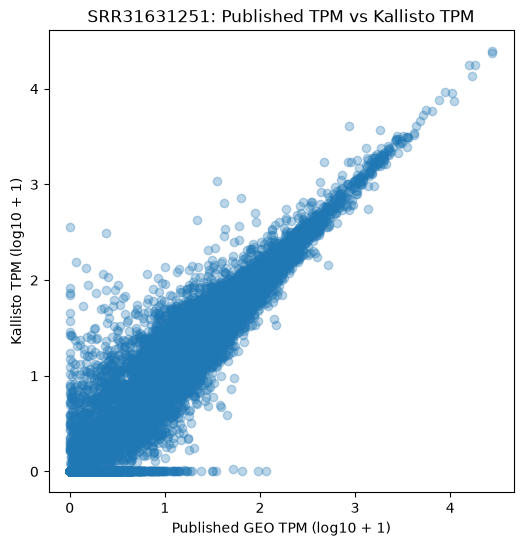

In [22]:
plt.figure(figsize=(6, 6))

plt.scatter(
    np.log10(comparison["geo_tpm"] + 1),
    np.log10(comparison["tpm"] + 1),
    alpha=0.3
)

plt.xlabel("Published GEO TPM (log10 + 1)")
plt.ylabel("Kallisto TPM (log10 + 1)")
plt.title("SRR31631251: Published TPM vs Kallisto TPM")

plt.savefig(
    "results/TPM_comparison_SRR31631251.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
corr = np.corrcoef(
    np.log10(comparison["geo_tpm"] + 1),
    np.log10(comparison["tpm"] + 1)
)[0, 1]

print("Correlation:", corr)

Correlation: 0.9631447699635629


In [24]:
def geo_column_name(condition, replicate):
    if condition == "siCTRL+IFNg":
        base = "siCTRL_with_IFN"
    elif condition == "siCTRL":
        base = "siCTRL_wo_IFN"
    elif condition == "siMITF+IFNg":
        base = "siMITF_with_IFN"
    elif condition == "siMITF":
        base = "siMITF_wo_IFN"

    return f"{base}_{replicate}"

In [25]:
samples["geo_column"] = samples.apply(
    lambda row: geo_column_name(
        row["condition"],
        row["replicate"]
    ),
    axis=1
)

samples[
    ["run_accession", "condition", "replicate", "geo_column"]
]

,run_accession,condition,replicate,geo_column
0,SRR31631262,siCTRL,1,siCTRL_wo_IFN_1
1,SRR31631258,siCTRL,2,siCTRL_wo_IFN_2
2,SRR31631254,siCTRL,3,siCTRL_wo_IFN_3
3,SRR31631261,siCTRL+IFNg,1,siCTRL_with_IFN_1
4,SRR31631257,siCTRL+IFNg,2,siCTRL_with_IFN_2
5,SRR31631253,siCTRL+IFNg,3,siCTRL_with_IFN_3
6,SRR31631260,siMITF,1,siMITF_wo_IFN_1
7,SRR31631256,siMITF,2,siMITF_wo_IFN_2
8,SRR31631252,siMITF,3,siMITF_wo_IFN_3
9,SRR31631259,siMITF+IFNg,1,siMITF_with_IFN_1


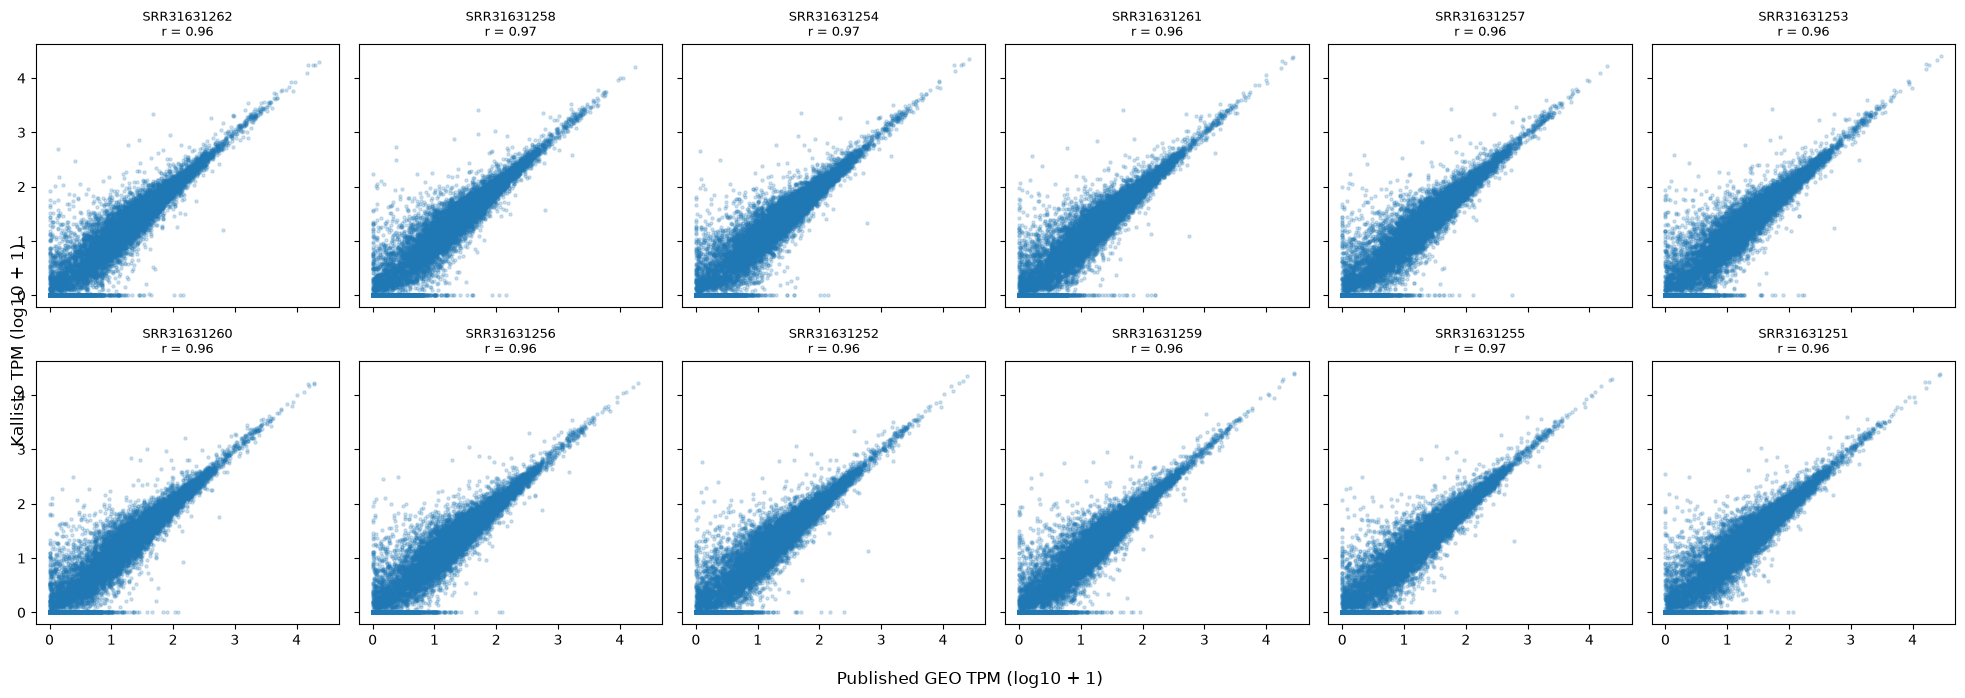

In [26]:
fig, axes = plt.subplots(
    2, 6,
    figsize=(20, 7),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# Matrix that will store gene-level TPM for all 12 samples
gene_tpm_all = None

for ax, (run, geo_col) in zip(
    axes,
    zip(samples["run_accession"], samples["geo_column"])
):

    # Read kallisto output for this sample
    kallisto = pd.read_csv(
        f"data/quant/{run}/abundance.tsv",
        sep="\t"
    )

    # Map transcript IDs to gene IDs
    kallisto_gene = kallisto.merge(
        t2g_small,
        left_on="target_id",
        right_on="transcript_id",
        how="inner"
    )

    # Sum transcript TPM values belonging to the same gene
    kallisto_gene_tpm = (
        kallisto_gene
        .groupby("gene_id", as_index=False)["tpm"]
        .sum()
    )

    # Add this sample to the matrix for PCA/heatmap
    gene_tpm = kallisto_gene_tpm.rename(
        columns={"tpm": run}
    )

    if gene_tpm_all is None:
        gene_tpm_all = gene_tpm
    else:
        gene_tpm_all = gene_tpm_all.merge(
            gene_tpm,
            on="gene_id",
            how="inner"
        )

    # Published GEO TPM for the matching sample
    geo_one = geo_tpm[
        ["Unnamed: 0", geo_col]
    ].copy()

    geo_one.columns = ["gene_id", "geo_tpm"]

    # Match kallisto gene TPM with published gene TPM
    comparison = kallisto_gene_tpm.merge(
        geo_one,
        on="gene_id",
        how="inner"
    )

    # Pearson correlation
    corr = np.corrcoef(
        np.log10(comparison["geo_tpm"] + 1),
        np.log10(comparison["tpm"] + 1)
    )[0, 1]

    # Scatter plot
    ax.scatter(
        np.log10(comparison["geo_tpm"] + 1),
        np.log10(comparison["tpm"] + 1),
        alpha=0.2,
        s=5
    )

    ax.set_title(
        f"{run}\nr = {corr:.2f}",
        fontsize=9
    )

fig.supxlabel("Published GEO TPM (log10 + 1)")
fig.supylabel("Kallisto TPM (log10 + 1)")

plt.tight_layout()

plt.savefig(
    "results/TPM_comparison_all_12_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save the gene_tmp_all to a file, if we need to restart VSC

In [27]:
gene_tpm_all.to_csv(
    "data/gene_tpm_all.csv",
    index=False
)

In [ ]:
import pandas as pd

gene_tpm_all = pd.read_csv(
    "data/gene_tpm_all.csv"
)

Creating a gene expression matrix for PCA and heatmap analysis

In [ ]:
pca_matrix = gene_tpm_all.set_index("gene_id")

pca_matrix = np.log10(pca_matrix + 1)

pca_input = pca_matrix.T

print(pca_input.shape)
pca_input.head()


(12, 39546)


gene_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000291291,ENSG00000291293,ENSG00000291294,ENSG00000291295,ENSG00000291296,ENSG00000291297,ENSG00000291298,ENSG00000291299,ENSG00000291300,ENSG00000291301
SRR31631262,1.064820,0.0,2.144349,1.081369,1.523459,0.0,0.000000,1.488286,1.449575,1.099972,...,0.0,0.0,0.0,0.0,0.519821,1.012608,0.0,0.509704,0.0,0.0
SRR31631258,1.064518,0.0,2.215696,1.016838,1.518458,0.0,0.000000,1.654042,1.536180,1.387429,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.331346,0.0,0.0
SRR31631254,0.842831,0.0,2.235345,0.674521,1.639431,0.0,0.692835,1.708219,1.476791,1.175276,...,0.0,0.0,0.0,0.0,0.527647,0.867956,0.0,1.191628,0.0,0.0
SRR31631261,1.238592,0.0,2.163943,0.871004,1.234828,0.0,0.771497,1.446121,1.159711,1.443743,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0
SRR31631257,1.133427,0.0,1.935141,1.239416,1.791025,0.0,0.484146,1.660618,1.490934,1.253692,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.436846,0.0,0.0


PCA calculation

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_scores = pca.fit_transform(pca_input)

print(pca_scores.shape)
print(pca.explained_variance_ratio_)

(12, 2)
[0.15374004 0.14483447]


In [35]:
pca_df = pd.DataFrame(
    pca_scores,
    columns=["PC1", "PC2"],
    index=pca_input.index
)

pca_df = pca_df.reset_index().rename(
    columns={"index": "run_accession"}
)

pca_df = pca_df.merge(
    samples[
        ["run_accession", "condition", "replicate"]
    ],
    on="run_accession",
    how="left"
)

pca_df

,run_accession,PC1,PC2,condition,replicate
0,SRR31631262,14.393298,-10.105267,siCTRL,1
1,SRR31631258,13.916475,-10.524724,siCTRL,2
2,SRR31631254,14.319496,-10.099923,siCTRL,3
3,SRR31631261,10.845241,14.562752,siCTRL+IFNg,1
4,SRR31631257,10.082673,11.787604,siCTRL+IFNg,2
5,SRR31631253,11.296721,11.569961,siCTRL+IFNg,3
6,SRR31631260,-12.542692,-13.908531,siMITF,1
7,SRR31631256,-11.621695,-14.767949,siMITF,2
8,SRR31631252,-10.922177,-13.105177,siMITF,3
9,SRR31631259,-14.157300,12.488935,siMITF+IFNg,1


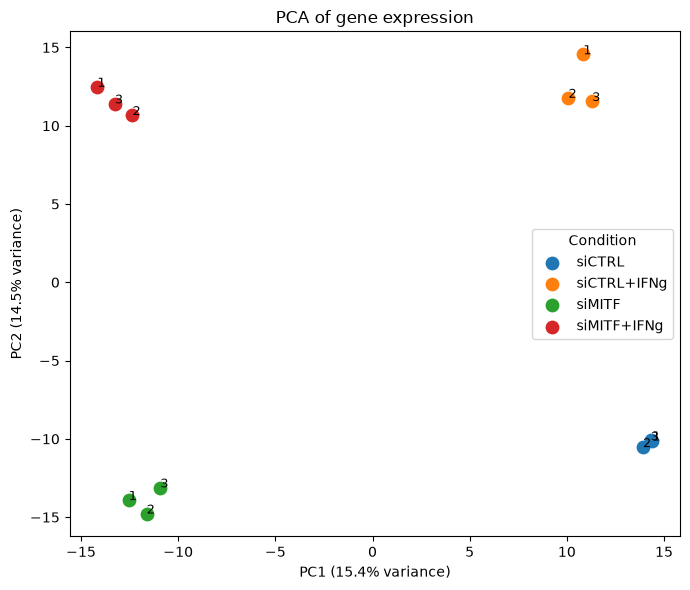

In [36]:
plt.figure(figsize=(7, 6))

for condition in pca_df["condition"].unique():
    subset = pca_df[pca_df["condition"] == condition]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=80,
        label=condition
    )

    for _, row in subset.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["replicate"]),
            fontsize=9
        )

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.title("PCA of gene expression")
plt.legend(title="Condition")

plt.tight_layout()

plt.savefig(
    "results/PCA_gene_expression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Histogram 

In [41]:
import scipy, scipy.signal
import numpy as np

In [38]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20,
                            'font.family':'sans-serif',
                            'xtick.labelsize':16,
                            'ytick.labelsize':16,
                            'figure.figsize':(16*(2/3), 9*(2/3)),
                            'axes.labelsize':20
                           })

In [42]:
expression = gene_tpm_all.set_index("gene_id")

substantial_expression = expression[
    expression.max(axis=1) >= 2
]

high_expression = expression[
    expression.max(axis=1) >= 100
]

print(substantial_expression.shape)
print(high_expression.shape)

(16420, 12)
(2687, 12)


In [44]:
log_expression = np.log2(substantial_expression + 1)
log_expression

,SRR31631262,SRR31631258,SRR31631254,SRR31631261,SRR31631257,SRR31631253,SRR31631260,SRR31631256,SRR31631252,SRR31631259,SRR31631255,SRR31631251
gene_id,,,,,,,,,,,,
ENSG00000000003,3.537256,3.536252,2.799823,4.114512,3.765163,3.702197,3.074519,4.185591,3.226265,4.122076,4.352817,4.158097
ENSG00000000419,7.123373,7.360383,7.425656,7.188462,6.428399,6.446755,7.533796,7.082121,6.965283,7.257026,6.872524,6.633727
ENSG00000000457,3.592230,3.377864,2.240711,2.893413,4.117250,3.829145,3.383494,3.134223,4.165184,3.478564,3.019922,3.944765
ENSG00000000460,5.060821,5.044210,5.446071,4.102011,5.949656,3.377379,4.281633,4.721142,4.685425,4.518383,4.614081,4.376787
ENSG00000000971,0.000000,0.000000,2.301550,2.562858,1.608298,2.685548,0.000000,0.000000,0.000000,2.789796,2.536585,2.884211
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291276,0.000000,1.680743,1.656332,0.000000,0.000000,1.665006,0.000000,0.000000,0.000000,1.641694,2.431901,0.000000
ENSG00000291296,1.726809,0.000000,1.752804,0.000000,0.000000,1.828412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291297,3.363812,0.000000,2.883288,0.000000,0.000000,3.819770,0.000000,2.095624,0.000000,2.047455,2.083983,0.000000


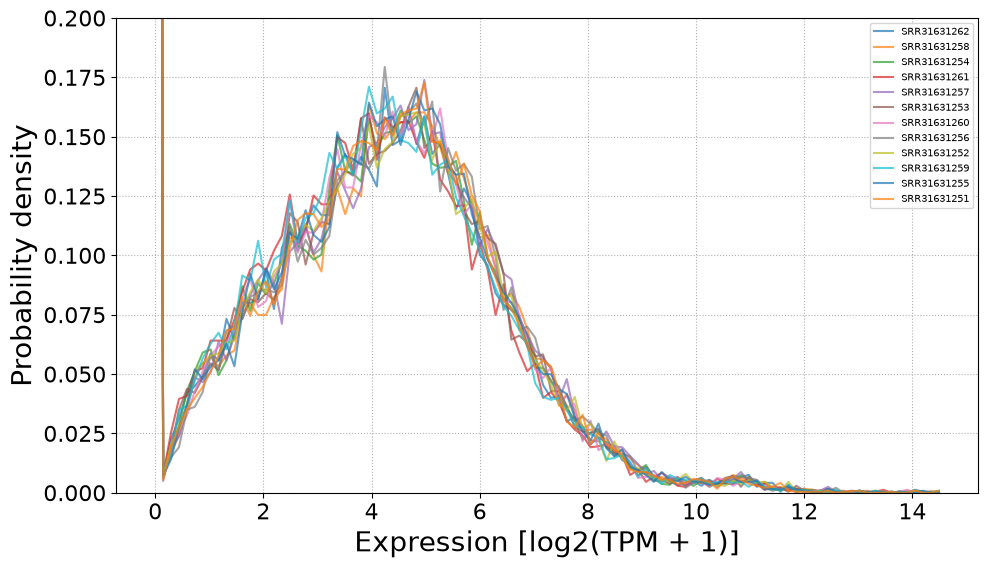

In [55]:
plt.figure(figsize=(10, 6))

for run in log_expression.columns:
    values = log_expression[run]

    hist, bin_edges = np.histogram(
        values,
        bins=100,
        range=(0, log_expression.to_numpy().max()),
        density=True
    )

    x = bin_edges[:-1]

    plt.plot(
        x,
        hist,
        label=run,
        alpha=0.7
    )

plt.xlabel("Expression [log2(TPM + 1)]")
plt.ylabel("Probability density")
plt.legend(fontsize=7)
plt.grid(ls=":")
plt.tight_layout()
plt.ylim(0, 0.2)
plt.savefig(
    "results/expression_histograms_all_samples.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Heatmap

In [28]:
import seaborn

In [29]:
heatmap_data = gene_tpm_all.set_index("gene_id")



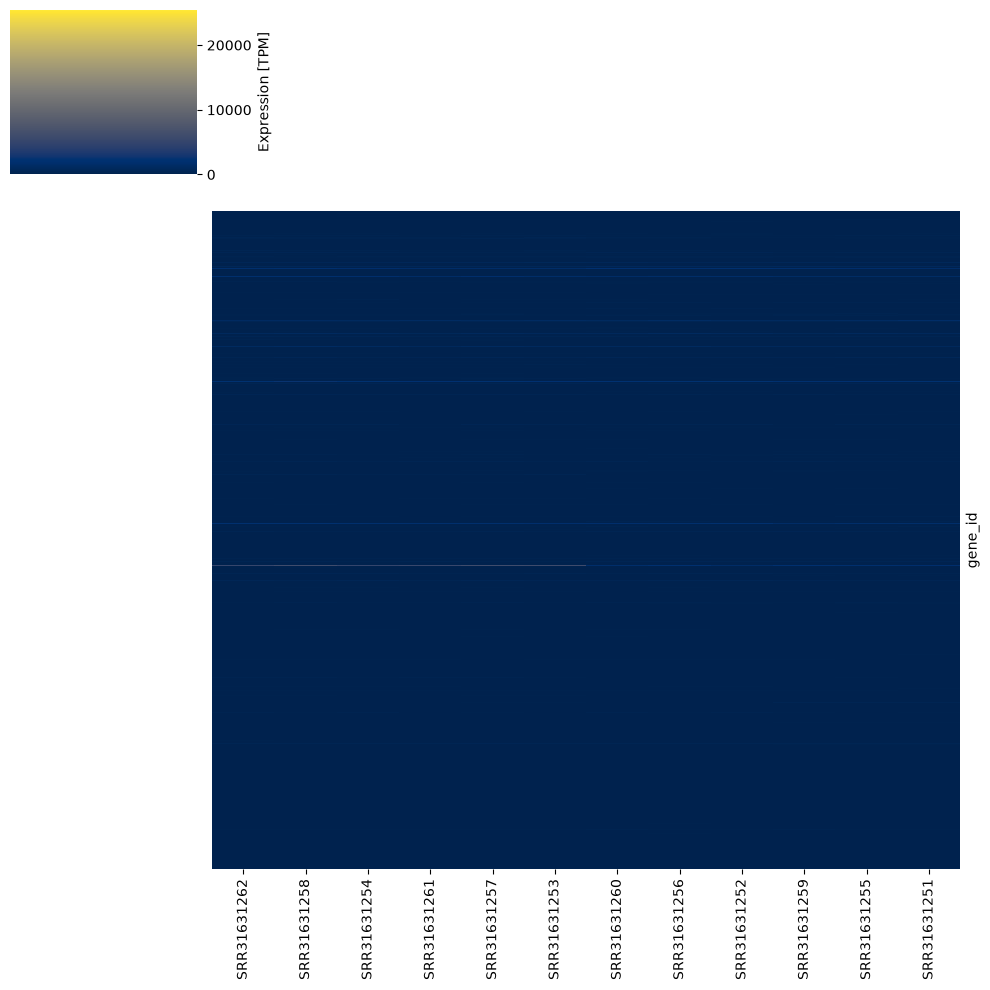

In [30]:
heatmap_16420 = heatmap_data[
    heatmap_data.max(axis=1) >= 2
]

g = seaborn.clustermap(
    heatmap_16420,
    cmap="cividis",
    row_cluster=False,
    col_cluster=False,
    yticklabels=False,
    cbar_kws={"label": "Expression [TPM]"}
)
g.savefig(
    "results/heatmap_TPM.png",
    dpi=300,
    bbox_inches="tight"
)
matplotlib.pyplot.tight_layout()

In [31]:
no_noise = heatmap_16420[heatmap_16420 .max(axis=1) > 2]

In [32]:
import scipy

In [33]:
zdf = scipy.stats.zscore(no_noise, axis=1)

/mnt/c/Users/Lenovo/OneDrive/Documents/2026_kursar/LÆK108E/GSE283655_project/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


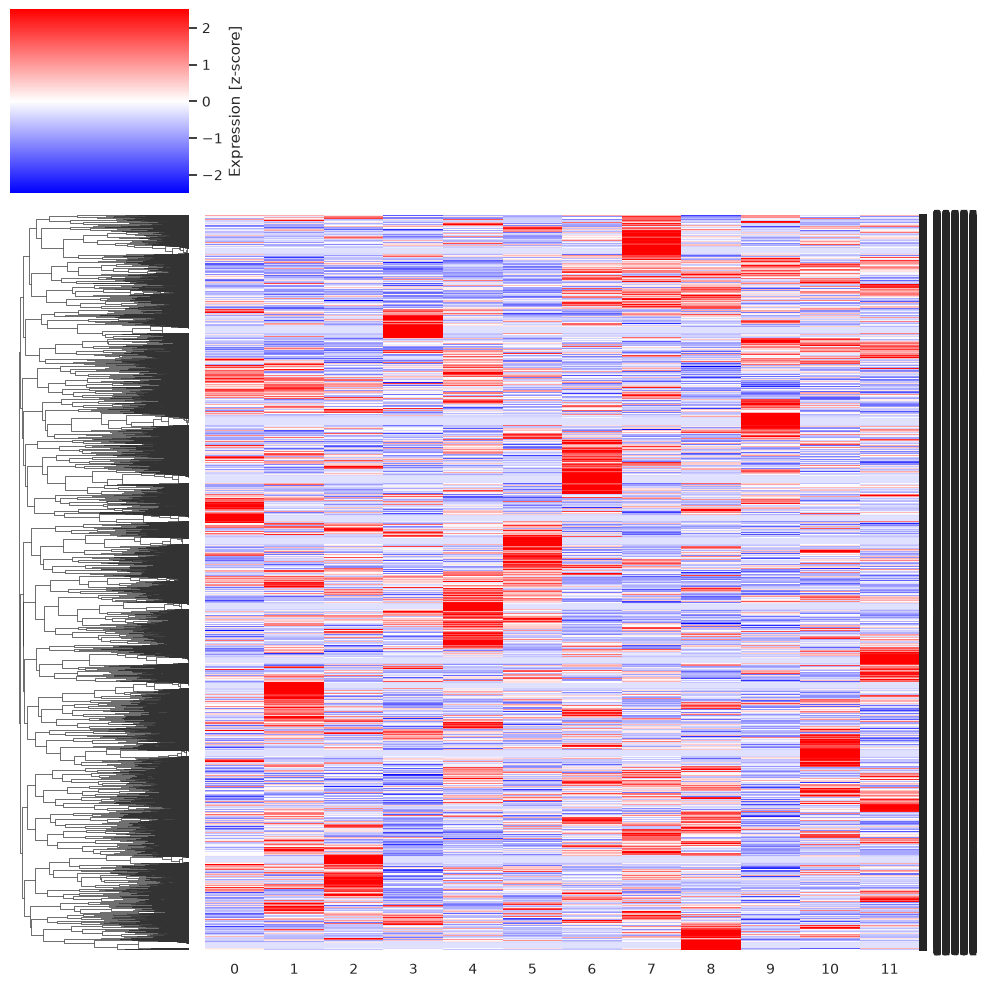

In [35]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
g_zscore =seaborn.clustermap(zdf,
                   cmap='bwr',
                   col_cluster=False,
                   vmin=-2.5, vmax=2.5,
                   method=linkage_method,
                   metric=distance_metric,
                   yticklabels=1,
                   cbar_kws={'label':'Expression [z-score]'})

g_zscore.savefig(
    "results/heatmap_TPM above 2.png",
    dpi=300,
    bbox_inches="tight"
)
matplotlib.pyplot.tight_layout()